# Simulation 1
Simulation 1 illustrates a minimal model of irritability using a single agent that can act either friendly or aggressively.  The agent experiences one unexpected nonreward, followed by a sequence of neutral outcomes, allowing us to isolate the emotional impact of a single frustrating event.  Anger/frustration is elicited by this event and then gradually decays over time in the absence of further negative feedback.  Importantly, the tendency to act aggressively is directly modulated by the current level of anger, leading to a temporary increase in aggressive behavior.  This setup captures the clinically relevant idea that irritability involves a prolonged and disproportionate response to an isolated frustration.

| Parameter | Range  | Interpretation |
|-----------|--------|----------------|
| θ_A_w1    | ℝ      | Reactive aggression gain: logit-linear scaling of aggressive behavior as a function of current anger/frustration |
| C         | [0, 1] | Perceived controllability of the environment |
| λ_A       | [0, 1] | Affective inertia: higher values → slower emotion updates |

In [1]:
import model
import importlib
importlib.reload(model)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mesa.visualization import SolaraViz, SpaceRenderer, make_plot_component
from mesa import batch_run
import numpy as np
import sys

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
pd.options.display.float_format = "{:.3f}".format

init_variables = {
    # Variables

    "V": 0,
    "M_A": 0,

    # prior tendencies for neutral behavior
    "theta_N_w0": 3.892,  # should yield around 95% neutral in the beginning

    # prior tendencies for friendly behavior
    "theta_F_w0": 0,

    # prior tendencies for aggressive behavior
    "theta_A_w0": 0,
    "theta_A_w1": range(-100, 0),

    # Parameters

    # Parameter for the exponential moving average of anger
    "lambda_A": np.linspace(0.6, 1, 10),

    # Controllability
    "C": np.linspace(0, 1, 50)
}

results = batch_run(
    model.IrritabilityModel,
    parameters=init_variables,
    data_collection_period=1,  # collect data for every step
    number_processes=16,
    max_steps=100,
)

results_df = pd.DataFrame(results)

results_df.to_parquet("output/001_fnr_impulse_response.parquet",
                      engine="pyarrow")

  0%|          | 0/50000 [00:00<?, ?it/s]

# Downcast data for dashboard

In [2]:
import pandas as pd
import gc

results_df = pd.read_parquet("output/001_fnr_impulse_response.parquet",
                             engine="pyarrow")

theta_vals = sorted(results_df["theta_A_w1"].unique())
C_vals     = sorted(results_df["C"].unique())
lambda_A_vals     = sorted(results_df["lambda_A"].unique())

meta_df = pd.DataFrame({
    "theta_vals": [theta_vals],
    "C_vals": [C_vals],
    "lambda_A_vals": [lambda_A_vals]
})

# Write to parquet
meta_df.to_parquet("output/dashboard/meta_info.parquet",
                   engine="pyarrow")

results_df.drop(columns=["AgentID", "RunId", "iteration", "r", "rpe", "seed"],
                inplace=True)

for c in results_df.select_dtypes(include="integer"):
    results_df[c] = pd.to_numeric(results_df[c], downcast="integer")

for c in results_df.select_dtypes(include="float"):
    results_df[c] = pd.to_numeric(results_df[c], downcast="float")

results_df.to_parquet(f"output/dashboard/001_fnr_impulse_response.parquet")

# A glimpse at the data

In [ ]:
results_df.head(n=200)

# Prior to the first step, many things are not defined (e.g. action)
results_df = results_df[results_df["Step"] > 0]

results_df.head(n=200)

results_df.columns

results_df["lambda_A"].unique()

Index(['Step', 'V', 'M_A', 'theta_N_w0', 'theta_F_w0', 'theta_A_w0',
       'theta_A_w1', 'theta_N', 'theta_A', 'theta_F', 'p_N', 'p_A', 'p_F',
       'lambda_A', 'C', 'a'],
      dtype='str')

# Some plots

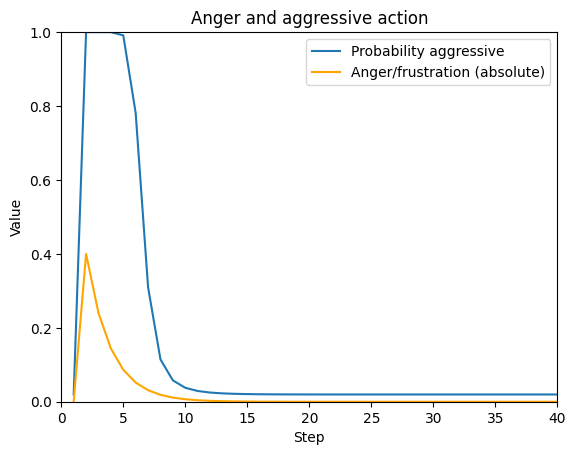

In [ ]:
data1 = results_df[(results_df["C"] == 1) &
           (results_df["theta_A_w1"] == -100) &
           (results_df["lambda_A"] == 0.6)]

g = sns.lineplot(data=data1,
                 y="p_A",
                 x="Step",
                 label="Probability aggressive")

g = sns.lineplot(data=data1,
                 y=data1["M_A"].abs(),
                 x="Step",
                 color="Orange",
                 label="Anger/frustration (absolute)")

g.set(title="Anger and aggressive action",
      ylabel="Value");

plt.xlim(0, 40)
plt.ylim(0, 1)
plt.show()